In [ ]:
%pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [5]:
%pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
    --------------------------------------- 0.5/39.5 MB 3.4 MB/s eta 0:00:12
   -- ------------------------------------- 2.9/39.5 MB 8.0 MB/s eta 0:00:05
   ----- ---------------------------------- 5.5/39.5 MB 9.9 MB/s eta 0:00:04
   ------ --------------------------------- 6.0/39.5 MB 8.0 MB/s eta 0:00:05
   ------ --------------------------------- 6.6/39.5 MB 6.8 MB/s eta 0:00:05
   ------- -------------------------------- 7.3/39.5 MB 6.7 MB/s eta 0:00:05
   -------- ------------------------------- 8.1/39.5 MB 6.0 MB/s eta 0:00:06
   --------- ------------------------------ 9.2/39.5 MB 5.6 MB/s eta 0:00:06
   --------- ------------------------------ 9.4/39.5 MB 5.2 MB/s eta 0:00:06
   ---------- ----------------------------- 10.2/39.5 MB 5.0 MB/s eta 0:00:06
   ----------- ---------------------------- 11.0/39.5 MB 4.8 MB/s eta 0:00:06
   

In [6]:
%pip install pillow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [8]:
%pip install patchify


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [9]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [10]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [18]:
import os
import cv2
from PIL import Image
import numpy as np
from patchify import patchify
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from matplotlib import pyplot as plt
import random

In [19]:
import os

# Define the local dataset path
dataset_root_folder = r"D:\Satellite"
dataset_name = "DubaiDataset"

# Full path to dataset
dataset_path = os.path.join(dataset_root_folder, dataset_name)

# List files in the directory (Equivalent to '!ls -lah' in Colab)
files = os.listdir(dataset_path)

# Display file names
for file in files:
    print(file)


classes.json
Tile 1
Tile 2
Tile 3
Tile 4
Tile 5
Tile 6
Tile 7
Tile 8


In [22]:
import os

# Define the dataset root folder
dataset_root_folder = r"D:\Satellite"

# Walk through all directories and files
for path, subdirs, files in os.walk(dataset_root_folder):
    dir_name = os.path.basename(path)  # Get last folder name
    # print(dir_name)  # Uncomment to debug

    if dir_name == 'masks':  # Change 'masks' to 'image' if needed
        print(f"Found masks folder: {path}")

        for image_name in files:
            if image_name.endswith('.png'):  # Check for PNG files
                print(f"Processing: {image_name}")  # Uncomment to debug
                a = True  # Placeholder for further processing


Found masks folder: D:\Satellite\DubaiDataset\Tile 1\masks
Processing: image_part_001.png
Processing: image_part_002.png
Processing: image_part_003.png
Processing: image_part_004.png
Processing: image_part_005.png
Processing: image_part_006.png
Processing: image_part_007.png
Processing: image_part_008.png
Processing: image_part_009.png
Found masks folder: D:\Satellite\DubaiDataset\Tile 2\masks
Processing: image_part_001.png
Processing: image_part_002.png
Processing: image_part_003.png
Processing: image_part_004.png
Processing: image_part_005.png
Processing: image_part_006.png
Processing: image_part_007.png
Processing: image_part_008.png
Processing: image_part_009.png
Found masks folder: D:\Satellite\DubaiDataset\Tile 3\masks
Processing: image_part_001.png
Processing: image_part_002.png
Processing: image_part_003.png
Processing: image_part_004.png
Processing: image_part_005.png
Processing: image_part_006.png
Processing: image_part_007.png
Processing: image_part_008.png
Processing: image

In [24]:
minmaxscalar = MinMaxScaler()

In [26]:
image_patch_size = 256

In [28]:
image = cv2.imread(f'{dataset_root_folder}/{dataset_name}/Tile 1/images/image_part_001.jpg',1)

In [30]:
image.shape

(644, 797, 3)

In [32]:
image_patches = patchify(image,(image_patch_size,image_patch_size,3),step=image_patch_size)

In [34]:
len(image_patches)

2

In [36]:
print(image_patches.shape)

(2, 3, 1, 256, 256, 3)


In [38]:
image_x = image_patches[0,0,:,:]
#MinMaxScaler
image_y = minmaxscalar.fit_transform(image_x.reshape(-1, image_x.shape[-1])).reshape(image_x.shape)

In [40]:
image_y[0].shape

(256, 256, 3)

In [42]:
print(type(image))

<class 'numpy.ndarray'>


In [44]:
type(Image.fromarray(image))

PIL.Image.Image

In [46]:
(image.shape[0]//image_patch_size) *image_patch_size

512

In [48]:
image_dataset = []
mask_dataset = []

for image_type in ['images', 'masks']:
  if image_type == 'images':
    image_extension = 'jpg'
  elif image_type == 'masks':
    image_extension = 'png'
  for tile_id in range(1,8):
    for image_id in range(1,20):
      image = cv2.imread(f'{dataset_root_folder}/{dataset_name}/Tile {tile_id}/{image_type}/image_part_00{image_id}.{image_extension}',1)
      if image is not None:
        if image_type == 'masks':
          image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        #print(image.shape)
        size_x = (image.shape[1]//image_patch_size) *image_patch_size
        size_y = (image.shape[0]//image_patch_size) *image_patch_size
        #print("{} --- {} - {}".format(image.shape, size_x, size_y))
        image = Image.fromarray(image)
        image = image.crop((0,0,size_x,size_y))
        image = np.array(image)
        patched_images = patchify(image,(image_patch_size,image_patch_size,3),step=image_patch_size)
        #print(len(patched_images))
        for i in range(patched_images.shape[0]):
          for j in range(patched_images.shape[1]):
            if image_type == 'images':
              individual_patched_image = patched_images[i,j,:,:]
              #print(individual_patched_image.shape)
              individual_patched_image = minmaxscalar.fit_transform(individual_patched_image.reshape(-1, individual_patched_image.shape[-1])).reshape(individual_patched_image.shape)
              individual_patched_image = individual_patched_image[0]
              #print(individual_patched_image.shape)
              image_dataset.append(individual_patched_image)
            elif image_type == 'masks':
              individual_patched_mask = patched_images[i,j,:,:]
              #individual_patched_mask = minmaxscalar.fit_transform(individual_patched_mask.reshape(-1, individual_patched_mask.shape[-1])).reshape(individual_patched_mask.shape)
              individual_patched_mask = individual_patched_mask[0]
              mask_dataset.append(individual_patched_mask)

In [50]:
print(len(image_dataset))
print(len(mask_dataset))

945
945


In [52]:
image_dataset = np.array(image_dataset)
mask_dataset = np.array(mask_dataset)

In [53]:
print(len(image_dataset))
print(len(mask_dataset))

945
945


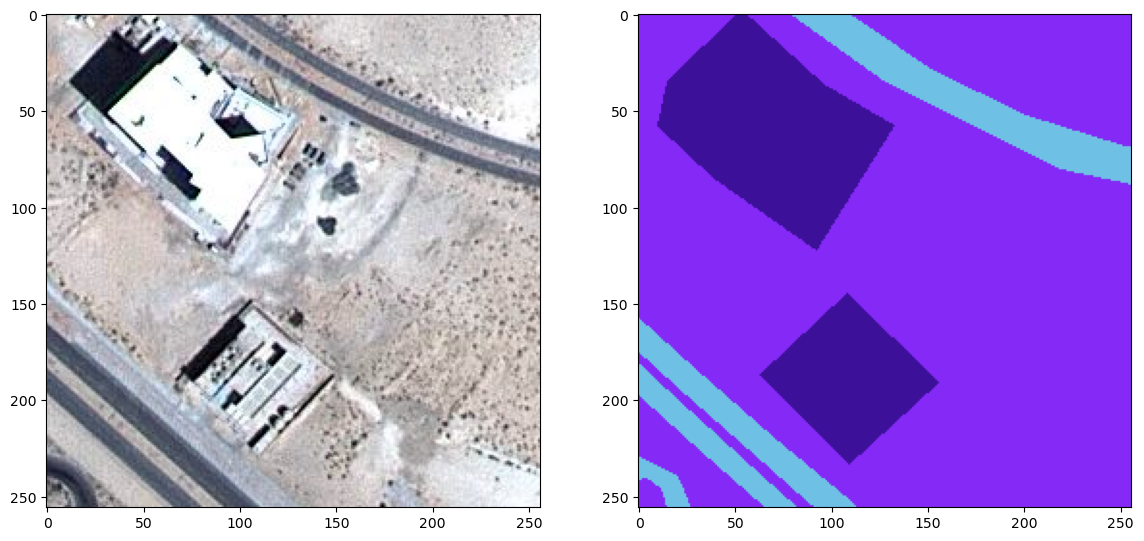

In [54]:
random_image_id = random.randint(0, len(image_dataset))  # viewing random images from the dataset
plt.figure(figsize = (14,8))
plt.subplot(121)
plt.imshow(image_dataset[random_image_id])
plt.subplot(122)
plt.imshow(mask_dataset[random_image_id])

In [55]:
class_building = '#3C1098'
class_building = class_building.lstrip('#')
class_building = np.array(tuple(int(class_building[i:i+2], 16) for i in (0, 2, 4)))
print(class_building)

class_land = '#8429F6'
class_land = class_land.lstrip('#')
class_land = np.array(tuple(int(class_land[i:i+2], 16) for i in (0, 2, 4)))
print(class_land)

class_road = '#6EC1E4'
class_road = class_road.lstrip('#')
class_road = np.array(tuple(int(class_road[i:i+2], 16) for i in (0, 2, 4)))
print(class_road)

class_vegetation = '#FEDD3A'
class_vegetation = class_vegetation.lstrip('#')
class_vegetation = np.array(tuple(int(class_vegetation[i:i+2], 16) for i in (0, 2, 4)))
print(class_vegetation)

class_water = '#E2A929'
class_water = class_water.lstrip('#')
class_water = np.array(tuple(int(class_water[i:i+2], 16) for i in (0, 2, 4)))
print(class_water)

class_unlabeled = '#9B9B9B'
class_unlabeled = class_unlabeled.lstrip('#')
class_unlabeled = np.array(tuple(int(class_unlabeled[i:i+2], 16) for i in (0, 2, 4)))
print(class_unlabeled)

[ 60  16 152]
[132  41 246]
[110 193 228]
[254 221  58]
[226 169  41]
[155 155 155]


In [60]:
mask_dataset.shape[0]

945

In [62]:
label = individual_patched_mask

In [64]:
def rgb_to_label(label):
  label_segment = np.zeros(label.shape,dtype=np.uint8)
  label_segment[np.all(label == class_water,axis = -1)] = 0
  label_segment[np.all(label == class_land,axis = -1)] = 1
  label_segment[np.all(label == class_road,axis = -1)] = 2
  label_segment[np.all(label == class_building,axis = -1)] = 3
  label_segment[np.all(label == class_vegetation,axis = -1)] = 4
  label_segment[np.all(label == class_unlabeled,axis = -1)] = 5
  #print(label_segment)
  label_segment = label_segment[:,:,0]
  #print(label_segment)
  return label_segment

In [66]:
labels = []
for i in range(mask_dataset.shape[0]):
  label = rgb_to_label(mask_dataset[i])
  labels.append(label)

In [67]:
print(len(labels))

945


In [68]:
label = np.array(labels)

In [69]:
labels[3]

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], dtype=uint8)

In [70]:
labels = np.expand_dims(labels, axis=3)

In [76]:
labels[0]

array([[[1],
        [1],
        [1],
        ...,
        [1],
        [1],
        [1]],

       [[1],
        [1],
        [1],
        ...,
        [1],
        [1],
        [1]],

       [[1],
        [1],
        [1],
        ...,
        [1],
        [1],
        [1]],

       ...,

       [[1],
        [1],
        [1],
        ...,
        [1],
        [1],
        [1]],

       [[1],
        [1],
        [1],
        ...,
        [1],
        [1],
        [1]],

       [[1],
        [1],
        [1],
        ...,
        [1],
        [1],
        [1]]], dtype=uint8)

In [78]:
np.unique(labels)

array([0, 1, 2, 3, 4, 5], dtype=uint8)

In [79]:
print("Total unique labels based on masks: ",format(np.unique(labels)))

Total unique labels based on masks:  [0 1 2 3 4 5]


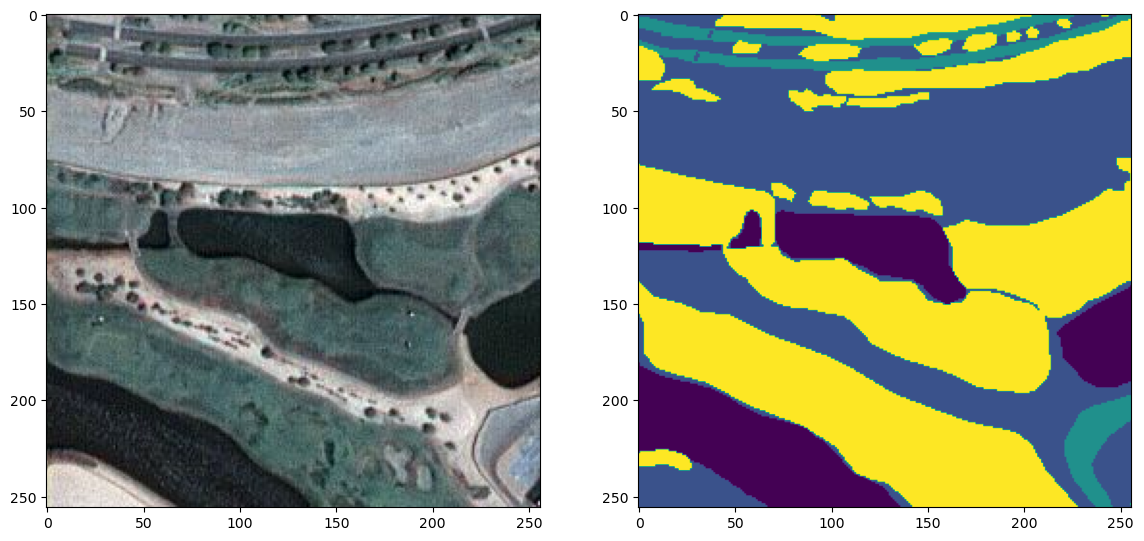

In [81]:
random_image_id = random.randint(0, len(image_dataset))

plt.figure(figsize=(14,8))
plt.subplot(121)
plt.imshow(image_dataset[random_image_id])
plt.subplot(122)
# plt.imshow(mask_dataset[random_image_id])
plt.imshow(labels[random_image_id][:,:,0])

In [84]:
total_classes = len(np.unique(labels))
total_classes

6

In [85]:
from tensorflow.keras.utils import to_categorical

In [86]:
labels_categorical_dataset = to_categorical(labels, num_classes=total_classes)

In [89]:
master_training_dataset = image_dataset

In [90]:
labels_categorical_dataset.shape

(945, 256, 256, 6)

In [91]:
#spliting the dataset to train test split
from sklearn.model_selection import train_test_split

In [92]:
X_train, X_test, y_train, y_test = train_test_split(master_training_dataset, labels_categorical_dataset, test_size =0.15, random_state = 100 )

In [93]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(803, 256, 256, 3)
(142, 256, 256, 3)
(803, 256, 256, 6)
(142, 256, 256, 6)


In [97]:
image_height = X_train.shape[1]
image_width = X_train.shape[2]
image_channels = X_train.shape[3]
total_classes = y_train.shape[3]

In [102]:
print(image_height)
print(image_width)
print(image_channels)
print(total_classes)

256
256
3
6


In [104]:
#Model Creating

In [106]:
!pip install numpy==1.26.4 tensorflow keras segmentation-models==1.0.1
import os
os.environ['SM_FRAMEWORK'] = 'tf.keras'
import segmentation_models as sm
print(sm.__version__)  # Check if the package loads correctly

Defaulting to user installation because normal site-packages is not writeable
Segmentation Models: using `tf.keras` framework.
1.0.1


In [108]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Conv2DTranspose
from keras.layers import concatenate, BatchNormalization, Dropout, Lambda

In [110]:
from keras import backend as K

In [112]:
from tensorflow.keras import backend as K  # Use tensorflow.keras.backend

def jaccard_coef(y_true, y_pred):
    y_true_flatten = K.flatten(y_true)
    y_pred_flatten = K.flatten(y_pred)
    intersection = K.sum(y_true_flatten * y_pred_flatten)

    return (intersection + 1.0) / (K.sum(y_true_flatten) + K.sum(y_pred_flatten) - intersection + 1.0)


In [114]:
import tensorflow.keras.backend as K

In [116]:
def multi_unet_model(n_classes=6, image_height=256, image_width=256, image_channels=1):
  inputs = Input((image_height, image_width, image_channels))
  source_input = inputs

  c1 = Conv2D(16, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(source_input)
  c1 = Dropout(0.2)(c1)
  c1 = Conv2D(16, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c1)
  p1 = MaxPooling2D((2,2))(c1)

  #we could change 32 as Hyper parmaeter tuning and also the dropout rate which is 0.2

  c2 = Conv2D(32, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(p1)
  c2 = Dropout(0.2)(c2)
  c2 = Conv2D(32, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c2)
  p2 = MaxPooling2D((2,2))(c2)

  #we could change 64 as Hyper parmaeter tuning and also the dropout rate which is 0.2

  c3 = Conv2D(64, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(p2)
  c3 = Dropout(0.2)(c3)
  c3 = Conv2D(64, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c3)
  p3 = MaxPooling2D((2,2))(c3)

  #we could change 128 as Hyper parmaeter tuning and also the dropout rate which is 0.2

  c4 = Conv2D(128, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(p3)
  c4 = Dropout(0.2)(c4)
  c4 = Conv2D(128, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c4)
  p4 = MaxPooling2D((2,2))(c4)

  #we could change 256 as Hyper parmaeter tuning and also the dropout rate which is 0.2
  c5 = Conv2D(256, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(p4)
  c5 = Dropout(0.2)(c5)
  c5 = Conv2D(256, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c5)


  u6 = Conv2DTranspose(128, (2,2), strides=(2,2), padding="same")(c5)
  u6 = concatenate([u6, c4])
  c6 = Conv2D(128, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(u6)
  c6 = Dropout(0.2)(c6)
  c6 = Conv2D(128, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c6)

  u7 = Conv2DTranspose(64, (2,2), strides=(2,2), padding="same")(c6)
  u7 = concatenate([u7, c3])
  c7 = Conv2D(64, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(u7)
  c7 = Dropout(0.2)(c7)
  c7 = Conv2D(64, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c7)

  u8 = Conv2DTranspose(32, (2,2), strides=(2,2), padding="same")(c7)
  u8 = concatenate([u8, c2])
  c8 = Conv2D(32, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(u8)
  c8 = Dropout(0.2)(c8)
  c8 = Conv2D(32, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c8)

  u9 = Conv2DTranspose(16, (2,2), strides=(2,2), padding="same")(c8)
  u9 = concatenate([u9, c1], axis=3)
  c9 = Conv2D(16, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(u9)
  c9 = Dropout(0.2)(c9)
  c9 = Conv2D(16, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c9)

  outputs = Conv2D(n_classes, (1,1), activation="softmax")(c9)

  model = Model(inputs=[inputs], outputs=[outputs])
  return model

In [118]:
metrics = ["accuracy", jaccard_coef]

In [120]:
def get_deep_learning_model():
  return multi_unet_model(n_classes=total_classes,
                          image_height=image_height,
                          image_width=image_width,
                          image_channels=image_channels)

In [122]:
model = get_deep_learning_model()

In [123]:
#Generating loss Function

In [124]:
weights = [0.166,0.166,0.166,0.166,0.166,0.166]

In [128]:
import segmentation_models as sm
print(sm.__version__)  #Check if the package loads correctly

1.0.1


In [130]:
dice_loss = sm.losses.DiceLoss(class_weights = weights)
focal_loss = sm.losses.CategoricalFocalLoss()
total_loss = dice_loss + (1 * focal_loss)

In [132]:
#Model Compilation

In [134]:
import tensorflow as tf

In [136]:
tf.keras.backend.clear_session()

In [137]:
model.compile(optimizer='adam', loss=total_loss, metrics=metrics)

In [138]:
from tensorflow.keras.utils import plot_model

In [142]:
%pip install pydot

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [143]:
plot_model(model, to_file="Satellite_model_plot.png", show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [144]:
import keras
from IPython.display import clear_output

%matplotlib inline

In [148]:
class PlotLoss(keras.callbacks.Callback):
  def on_train_begin(self, logs={}):
    self.i = 0
    self.x = []
    self.losses = []
    self.val_losses = []
    self.jaccards_coef = []
    self.val_jaccards_coef = []
    self.fig = plt.figure()
    self.logs = []

    def on_epoch_end(self, epoch, logs={}):
      self.logs.append(logs)
      self.x.append(self.i)

      #self.losses.append(logs.get('loss'))
      #self.val_losses.append(logs.get('val_loss'))

      self.jaccards_coef.append(logs.get('jaccard_coef'))
      self.val_jaccards.append(logs.get('val_jaccard_coef'))

      self.i += 1

      clear_output(wait=True)
      #plt.plot(self.x, self.losses, label="loss")
      #plt.plot(self.x, self.val_losses, label="val_loss")

      plt.plot(self.x, self.jaccards_coef, label="jaccards_coef")
      plt.plot(self.x, self.val_jaccards, label="val_jaccards_coef")
      plt.legend()
      plt.show();

plot_loss =  PlotLoss()

In [150]:
class PlotLossEx(keras.callbacks.Callback):
  def on_train_begin(self, logs={}):
    self.i = 0
    self.x = []

    self.losses = []
    self.val_losses = []

    self.jaccards_coef = []
    self.val_jaccards_coef = []

    self.fig = plt.figure()
    self.logs = []

    def on_epoch_end(self, epoch, logs={}):
      self.logs.append(logs)
      self.x.append(self.i)

      #self.losses.append(logs.get('loss'))
      #self.val_losses.append(logs.get('val_loss'))

      self.jaccards_coef.append(logs.get('jaccard_coef'))
      self.val_jaccards.append(logs.get('val_jaccard_coef'))

      self.i += 1

      clear_output(wait=True)
      #plt.plot(self.x, self.losses, label="loss")
      #plt.plot(self.x, self.val_losses, label="val_loss")

      plt.plot(self.x, self.jaccards_coef, label="jaccards_coef")
      plt.plot(self.x, self.val_jaccards, label="val_jaccards_coef")
      plt.legend()
      plt.show();

plot_loss =  PlotLossEx()

In [152]:
model_history = model.fit(X_train, y_train,
                          batch_size=16,
                          verbose=1,
                          epochs=200, #100
                          validation_data=(X_test, y_test),
                          callbacks=[plot_loss],
                          shuffle=False)

Epoch 1/100


C:\Users\Deepak\AppData\Roaming\Python\Python312\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 256, 256, 3))
  warnings.warn(msg)


51/51 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.5203 - jaccard_coef: 0.2342 - loss: 1.0066 - val_accuracy: 0.6557 - val_jaccard_coef: 0.3091 - val_loss: 0.9915
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.6576 - jaccard_coef: 0.3241 - loss: 0.9906 - val_accuracy: 0.6702 - val_jaccard_coef: 0.3174 - val_loss: 0.9862
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.6951 - jaccard_coef: 0.4139 - loss: 0.9722 - val_accuracy: 0.6459 - val_jaccard_coef: 0.4164 - val_loss: 1.0027
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.7393 - jaccard_coef: 0.4919 - loss: 0.9582 - val_accuracy: 0.6506 - val_jaccard_coef: 0.4480 - val_loss: 0.9959
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.7527 - jaccard_coef: 0.5202 - loss: 0.9510 - val_accuracy: 0.6250 - val_jaccard_coef: 0.4101 - val_loss: 1.0036
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.7593 - jaccard_coef: 0.5304 - loss: 0.9487 - val_accuracy: 0.6

In [154]:
history_a = model_history

In [156]:
loss = history_a.history['loss']
val_loss = history_a.history['val_loss']

In [158]:
val_loss

[0.991484522819519,
 0.9861767292022705,
 1.0027250051498413,
 0.995908260345459,
 1.0035889148712158,
 0.9947301149368286,
 0.9960792660713196,
 0.9803105592727661,
 0.9709036350250244,
 0.9705271124839783,
 0.9578844308853149,
 0.9522306323051453,
 0.951456606388092,
 0.9441823959350586,
 0.9431907534599304,
 0.9385638236999512,
 0.9370875954627991,
 0.931289792060852,
 0.9427819848060608,
 0.9433399438858032,
 0.9306272268295288,
 0.9258980751037598,
 0.9284140467643738,
 0.9255562424659729,
 0.9248437881469727,
 0.9264332056045532,
 0.9251220226287842,
 0.9274131655693054,
 0.9213753342628479,
 0.919297456741333,
 0.9173212051391602,
 0.9190230965614319,
 0.9240056276321411,
 0.9209007024765015,
 0.918927788734436,
 0.9209360480308533,
 0.9297995567321777,
 0.9164016246795654,
 0.9267439246177673,
 0.925736665725708,
 0.9212529063224792,
 0.9164711236953735,
 0.9172070026397705,
 0.9195535182952881,
 0.9161983132362366,
 0.9216701984405518,
 0.9185054898262024,
 0.916578471660614,


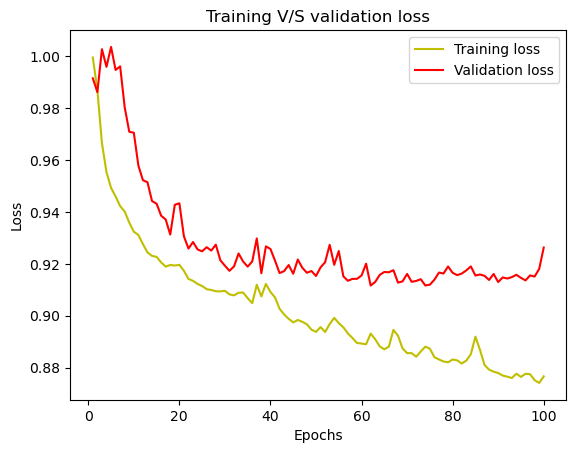

In [160]:
loss = history_a.history['loss']
val_loss = history_a.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training V/S validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

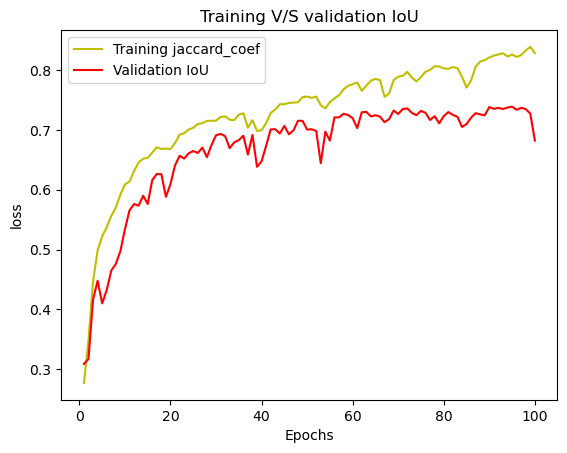

In [162]:
jaccard_coef = history_a.history['jaccard_coef']
val_jaccard_coef = history_a.history['val_jaccard_coef']

epochs = range(1, len(jaccard_coef) + 1)
plt.plot(epochs, jaccard_coef, 'y', label='Training jaccard_coef')
plt.plot(epochs, val_jaccard_coef, 'r', label='Validation IoU')
plt.title('Training V/S validation IoU')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [164]:
model_history.params

{'verbose': 1, 'epochs': 100, 'steps': 51}

In [166]:
y_pred = model.predict(X_test)

C:\Users\Deepak\AppData\Roaming\Python\Python312\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 256, 256, 3))
  warnings.warn(msg)


5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step


In [168]:
len(y_pred)

142

In [170]:
y_pred_argmax = np.argmax(y_pred, axis=3)

In [172]:
len(y_pred_argmax)

142

In [174]:
y_pred_argmax

array([[[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1]],

       [[0, 0, 0, ..., 0, 0, 4],
        [0, 0, 0, ..., 0, 0, 4],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[1, 1, 2, ..., 1, 1, 1],
        [1, 1, 2, ..., 1, 1, 1],
        [1, 2, 2, ..., 1, 1, 1],
        ...,
        [2, 2, 2, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]],

       ...,

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 4, 4, 4],
        [1, 1, 1, ..., 4, 4, 4],
        [1, 1, 1, ..., 4, 4, 4]],

       [[0, 0, 0, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [176]:
y_test_argmax = np.argmax(y_test, axis=3)

In [178]:
y_test_argmax

array([[[3, 3, 3, ..., 1, 1, 1],
        [3, 3, 3, ..., 3, 3, 3],
        [3, 3, 3, ..., 3, 3, 3],
        ...,
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[2, 2, 2, ..., 1, 1, 1],
        [2, 2, 2, ..., 1, 1, 1],
        [2, 2, 2, ..., 1, 1, 1],
        ...,
        [2, 2, 2, ..., 0, 0, 0],
        [2, 2, 2, ..., 0, 0, 0],
        [2, 2, 1, ..., 0, 0, 0]],

       ...,

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [180]:
#Compairing prediction results
#using test images using mask images and predicted result images

In [182]:
import random

In [196]:
test_image_number = random.randint(0, len(X_test))

test_image = X_test[test_image_number]
ground_truth_image = y_test_argmax[test_image_number]

test_image_input = np.expand_dims(test_image, axis=0)

prediction = model.predict(test_image_input)
predicted_image = np.argmax(prediction, axis=3)
predicted_image = predicted_image[0,:,:]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


In [198]:
plt.figure(figsize = (14,8))
plt.subplot(231)
plt.title("Original Image")
plt.imshow(test_image)
plt.subplot(232)
plt.title("Original Masked Image")
plt.imshow(ground_truth_image)
plt.subplot(233)
plt.title("Predicted Image")
plt.imshow(predicted_image)

In [200]:
model.save("satellite_segmentation_full.h5")

In [202]:
#model.save("D:/SAR MODEL/satellite_segmentation_full.h5")

In [204]:
#model.save("D:/SAR MODEL/satellite_segmentation_full.keras")

In [206]:
model.save("D:/SAR MODEL/satellite_segmentation_full.keras")